In [ ]:
# === Upgrade Java to version 21 for SPMF compatibility ===
!apt-get update -y
!apt-get install -y openjdk-21-jdk
!java -version

Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Hit:2 https://cli.github.com/packages stable InRelease
Get:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:5 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:8 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,125 kB]
Get:9 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:10 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:11 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [2,826 kB]
Get:12 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 Packages [3,857 kB]
Hit:13 https://ppa.launchpadcontent.net/graphics-drivers/p

In [ ]:
import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-21-openjdk-amd64"
os.environ["PATH"] += os.pathsep + "/usr/lib/jvm/java-21-openjdk-amd64/bin"

In [ ]:
# ============================================================
# E(3A)CSPM: Employee Attrition Prediction (HRA dataset only)
# ============================================================

import pandas as pd, numpy as np, os, subprocess, time
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from imblearn.over_sampling import SMOTE

# ---------- Download SPMF ----------
def download_spmf():
    if not os.path.exists("spmf.jar"):
        print("Downloading SPMF...")
        subprocess.run(["wget","-q","-O","spmf.jar",
                        "http://www.philippe-fournier-viger.com/spmf/spmf.jar"])
        print("SPMF downloaded")
    else:
        print("SPMF already exists")

# ---------- Model Dictionary ----------
def model_dict():
    return {
        "MNB": MultinomialNB(alpha=1.0),
        "GNB": GaussianNB(),
        "DT": DecisionTreeClassifier(random_state=42),
        "RF": RandomForestClassifier(n_estimators=100, random_state=42),
        "MLP": MLPClassifier(hidden_layer_sizes=(400,), activation='tanh',
                             solver='adam', max_iter=1500, random_state=42),
        "SVM": SVC(kernel='rbf', gamma='scale', random_state=42),
        "kNN": KNeighborsClassifier(n_neighbors=3),
        "LR": LogisticRegression(max_iter=500, random_state=42)
    }

# ---------- Load dataset ----------
def load_dataset(path, target_col):
    df = pd.read_csv(path)
    print(f"Loaded {path}: {df.shape[0]} rows, {df.shape[1]} columns")
    df = df.fillna("Unknown").astype(str)
    return df, target_col

# ---------- Create mapping & SPMF input ----------
def create_mapping(df):
    mapping = {}
    idx = 1
    for col in df.columns:
        for val in df[col].unique():
            mapping[(col, val)] = idx
            idx += 1
    print(f"Created mapping with {len(mapping)} unique items")
    return mapping

def to_spmf(df, mapping, filename):
    seqs = []
    for _, row in df.iterrows():
        s = []
        prev = None
        for c in df.columns:
            item = mapping[(c, row[c])]
            if item != prev:
                s.append(str(item))
                s.append("-1")
                prev = item
        s.append("-2")
        seqs.append(" ".join(s))
    with open(filename, "w") as f:
        f.write("\n".join(seqs))
    print(f"Saved {len(seqs)} sequences → {filename}")

# ---------- Run TKS and ERMiner ----------
def run_tks(inp, out, k=500):
    print(f"Running TKS (k={k})")
    res = subprocess.run(["java","-Xmx4g","-jar","spmf.jar","run","TKS",inp,out,str(k)],
                         capture_output=True, text=True)
    print("TKS completed" if res.returncode == 0 else f"TKS failed: {res.stderr}")

def run_erminer(inp, out, minsup="50%", minconf="60%"):
    print(f"Running ERMiner (minsup={minsup}, minconf={minconf})")
    res = subprocess.run(["java","-Xmx4g","-jar","spmf.jar","run","ERMiner",inp,out,minsup,minconf],
                         capture_output=True, text=True)
    print("ERMiner completed" if res.returncode == 0 else f"ERMiner failed: {res.stderr}")

# ---------- Case 1: Original Features ----------
def case1(df, target, dataset):
    print(f"\n{'='*60}\nCASE 1: {dataset} – Original Features\n{'='*60}")
    df = df.copy()
    le = LabelEncoder()
    for c in df.select_dtypes(include='object').columns:
        if c != target:
            df[c] = le.fit_transform(df[c])
    df[target] = le.fit_transform(df[target])
    X = df.drop(columns=[target])
    y = df[target]
    X = MinMaxScaler().fit_transform(X)
    models = model_dict()
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    print("\n Without SMOTE")
    for n, m in models.items():
        t = time.time()
        scores = cross_val_score(m, X, y, cv=cv, scoring='accuracy')
        print(f"{n}: {scores.mean()*100:.2f}% ({time.time()-t:.2f}s)")

    print("\n With SMOTE")
    for n, m in models.items():
        t = time.time()
        sm_scores = []
        for tr, ts in cv.split(X, y):
            Xtr, Xts = X[tr], X[ts]
            ytr, yts = y.iloc[tr], y.iloc[ts]
            Xr, yr = SMOTE(random_state=42).fit_resample(Xtr, ytr)
            m.fit(Xr, yr)
            sm_scores.append(m.score(Xts, yts))
        print(f"{n}: {np.mean(sm_scores)*100:.2f}% ({time.time()-t:.2f}s)")

# ---------- Case 2: Sequential Pattern Features ----------
def parse_tks(file):
    patterns = []
    if not os.path.exists(file):
        return patterns
    for line in open(file):
        if "#SUP:" in line:
            p, _ = line.split("#SUP:")
            items = [int(x) for x in p.split() if x not in ["-1", "-2", ""]]
            if len(items) >= 2:
                patterns.append(items)
    print(f"Parsed {len(patterns)} patterns from {file}")
    return patterns[:100]  # top 100

def pattern_features(df, mapping, patterns, target):
    rev = {v: (c, val) for (c, val), v in mapping.items()}
    df_s = df.astype(str)
    n = len(df)
    mat = np.zeros((n, len(patterns)), dtype=np.int8)
    for i, p in enumerate(patterns):
        pairs = [rev[x] for x in p if x in rev]
        for r in range(n):
            if all(df_s.iloc[r][c] == val for c, val in pairs):
                mat[r, i] = 1
    feat = pd.DataFrame(mat, columns=[f"P{i+1}" for i in range(len(patterns))])
    feat[target] = df[target].values
    print(f"Created pattern feature matrix: {feat.shape}")
    return feat

def case2(df, mapping, patterns, target, dataset):
    print(f"\n{'='*60}\nCASE 2: {dataset} – Sequential Pattern Features\n{'='*60}")
    dfp = pattern_features(df, mapping, patterns, target)
    X = dfp.drop(columns=[target])
    y = LabelEncoder().fit_transform(dfp[target])
    X = MinMaxScaler().fit_transform(X)
    models = model_dict()
    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    for n, m in models.items():
        t = time.time()
        scores = cross_val_score(m, X, y, cv=cv, scoring='accuracy')
        print(f"{n}: {scores.mean()*100:.2f}% ({time.time()-t:.2f}s)")

# ---------- MAIN ----------
def main():
    download_spmf()
    df, target = load_dataset("hr_data.csv", "left")
    mapping = create_mapping(df)
    to_spmf(df, mapping, "hra_spmf_input.txt")
    run_tks("hra_spmf_input.txt", "hra_tks.txt")
    run_erminer("hra_spmf_input.txt", "hra_rules.txt")
    case1(df, target, "HRA")
    pats = parse_tks("hra_tks.txt")
    if pats:
        case2(df, mapping, pats, target, "HRA")
    print("\nAll evaluations complete!")

# ---------- Run ----------
if __name__ == "__main__":
    main()

SPMF downloaded
Loaded hr_data.csv: 14999 rows, 11 columns
Created mapping with 410 unique items
Saved 14999 sequences → hra_spmf_input.txt
Running TKS (k=500)
TKS completed
Running ERMiner (minsup=50%, minconf=60%)
ERMiner completed

CASE 1: HRA – Original Features

 Without SMOTE
MNB: 76.19% (0.03s)
GNB: 79.66% (0.03s)
DT: 97.69% (0.17s)
RF: 98.99% (4.73s)
MLP: 96.29% (317.73s)
SVM: 94.60% (7.48s)
kNN: 95.38% (0.70s)
LR: 76.67% (0.15s)

 With SMOTE
MNB: 58.76% (0.41s)
GNB: 55.32% (0.37s)
DT: 97.39% (0.74s)
RF: 98.90% (8.95s)
MLP: 94.93% (409.59s)
SVM: 93.89% (21.21s)
kNN: 94.77% (1.34s)
LR: 77.94% (0.78s)
Parsed 479 patterns from hra_tks.txt

CASE 2: HRA – Sequential Pattern Features
Created pattern feature matrix: (14999, 101)
MNB: 94.62% (0.08s)
GNB: 87.24% (0.19s)
DT: 98.13% (0.75s)
RF: 98.19% (8.95s)
MLP: 98.17% (76.66s)
SVM: 98.21% (9.16s)
kNN: 94.58% (1.57s)
LR: 98.21% (1.38s)

All evaluations complete!


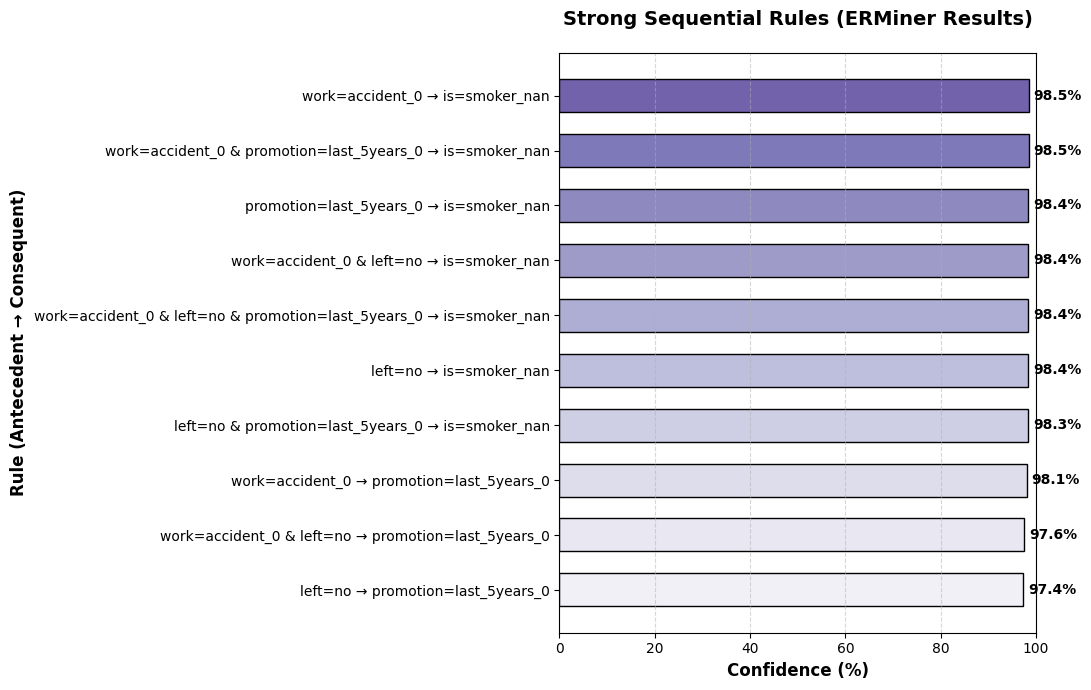

In [ ]:
# ============================================================
# 1. Parse ERMiner Rules + Decode with Real Feature Names
# ============================================================
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- Load HRA Dataset to Build Feature → ID Mapping ---
df = pd.read_csv("hr_data.csv")  # Your original HRA CSV

# Build (feature, value) → ID mapping
FEATURE_TO_ID = {}
current_id = 1
for col in df.columns:
    for val in df[col].unique():
        key = f"{col}_{val}"
        FEATURE_TO_ID[key] = current_id
        current_id += 1

# Reverse: ID → (col, val)
ID_TO_FEATURE = {v: k for k, v in FEATURE_TO_ID.items()}

# --- Parse ERMiner Rules ---
def parse_erminer_rules(file_path):
    rules = []
    with open(file_path, 'r') as f:
        for line in f:
            if '#SUP:' in line and '#CONF:' in line:
                parts = line.strip().split(' ==> ')
                if len(parts) != 2: continue
                antecedent_str, rest = parts
                consequent_str, sup_conf = rest.split('#SUP:')
                sup_part, conf_part = sup_conf.split('#CONF:')

                antecedent = [int(x) for x in antecedent_str.split(',') if x.strip().isdigit()]
                consequent = [int(x) for x in consequent_str.split() if x.strip().isdigit()]
                support = int(sup_part.strip())
                confidence = float(conf_part.strip())

                rules.append({
                    'antecedent': antecedent,
                    'consequent': consequent,
                    'support': support,
                    'confidence': confidence
                })
    return rules

# --- Decode Rule ---
def decode_rule(antecedent_ids, consequent_ids):
    ant_dec = []
    for aid in antecedent_ids:
        if aid in ID_TO_FEATURE:
            col_val = ID_TO_FEATURE[aid]
            col = col_val.split('_', 1)[0]
            val = col_val.split('_', 1)[1]
            ant_dec.append(f"{col}={val}")
        else:
            ant_dec.append(f"ID_{aid}")

    con_dec = []
    for cid in consequent_ids:
        if cid in ID_TO_FEATURE:
            col_val = ID_TO_FEATURE[cid]
            col = col_val.split('_', 1)[0]
            val = col_val.split('_', 1)[1]
            con_dec.append(f"{col}={val}")
        else:
            con_dec.append(f"ID_{cid}")

    ant_str = " & ".join(ant_dec) if len(ant_dec) > 1 else ant_dec[0] if ant_dec else ""
    con_str = ", ".join(con_dec)
    return f"{ant_str} → {con_str}" if ant_str else f"→ {con_str}"

# ============================================================
# 2. Parse & Decode Top 10 Rules by Confidence
# ============================================================
rules_file = "hra_rules.txt"

rules = parse_erminer_rules(rules_file)

# Sort by confidence descending
rules.sort(key=lambda x: x['confidence'], reverse=True)
top_rules = rules[:10]

decoded_rules = []
confidences = []
for r in top_rules:
    rule_text = decode_rule(r['antecedent'], r['consequent'])
    decoded_rules.append(rule_text)
    confidences.append(r['confidence'] * 100)  # to %

# ============================================================
# 3. Publication-Style Horizontal Bar Chart (Purple Gradient)
# ============================================================
plt.figure(figsize=(11, 7))
colors = plt.cm.Purples_r(np.linspace(0.3, 0.9, len(decoded_rules)))  # Purple gradient

# Reverse for highest on top
decoded_rules = decoded_rules[::-1]
confidences = confidences[::-1]
colors = colors[::-1]

bars = plt.barh(decoded_rules, confidences, color=colors, edgecolor='black', height=0.6)

plt.xlabel('Confidence (%)', fontsize=12, fontweight='bold')
plt.ylabel('Rule (Antecedent → Consequent)', fontsize=12, fontweight='bold')
plt.title('Strong Sequential Rules (ERMiner Results)', fontsize=14, fontweight='bold', pad=20)

# Add confidence labels
for i, (bar, conf) in enumerate(zip(bars, confidences)):
    plt.text(conf + 1, bar.get_y() + bar.get_height()/2, f'{conf:.1f}%',
             va='center', ha='left', fontsize=10, fontweight='bold')

plt.xlim(0, 100)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()

# Save
plt.savefig("Strong_Sequential_Rules_ERMiner_HRA.png", dpi=300, bbox_inches='tight')
plt.show()

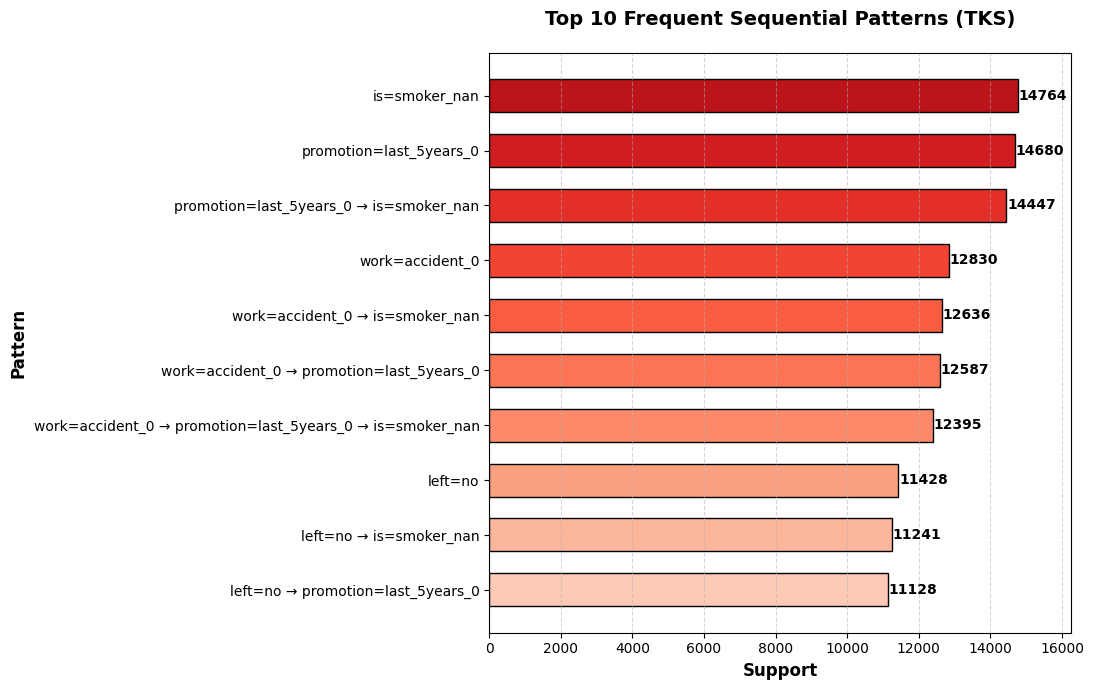

In [ ]:
# ============================================================
# 1. Parse TKS Output + Decode with Real Feature Names
# ============================================================
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- Load HRA Dataset to Build Feature → ID Mapping ---
df = pd.read_csv("hr_data.csv")  # Your original HRA CSV (e.g., from Kaggle)
# Assuming columns: satisfaction_level, last_evaluation, number_project, average_montly_hours, time_spend_company, Work_accident, promotion_last_5years, sales (Department), salary, left

# Build (feature, value) → ID mapping
FEATURE_TO_ID = {}
current_id = 1
for col in df.columns:
    for val in df[col].unique():
        key = f"{col}_{val}"
        FEATURE_TO_ID[key] = current_id
        current_id += 1

# Reverse: ID → (col, val)
ID_TO_FEATURE = {v: k for k, v in FEATURE_TO_ID.items()}

# --- Parse TKS Patterns ---
def parse_tks_patterns(file_path):
    patterns = []
    with open(file_path, 'r') as f:
        for line in f:
            if '#SUP:' in line:
                patt_part, sup_part = line.strip().split('#SUP:')
                items = [int(x) for x in patt_part.split() if x not in ['-1', '-2']]
                support = int(sup_part.strip())
                if len(items) >= 1:
                    patterns.append((items, support))
    # Sort by support descending
    patterns.sort(key=lambda x: x[1], reverse=True)
    return patterns[:10]  # Top 10

# --- Decode Pattern ---
def decode_pattern(pattern_ids):
    decoded = []
    for pid in pattern_ids:
        if pid in ID_TO_FEATURE:
            col_val = ID_TO_FEATURE[pid]
            col = col_val.split('_', 1)[0]
            val = col_val.split('_', 1)[1]
            decoded.append(f"{col}={val}")
        else:
            decoded.append(f"ID_{pid}")
    return " → ".join(decoded)

# ============================================================
# 2. Parse & Decode Top 10 Patterns by Support
# ============================================================
tks_file = "hra_tks.txt"

top_patterns = parse_tks_patterns(tks_file)

decoded_patterns = []
supports = []
for items, sup in top_patterns:
    rule_text = decode_pattern(items)
    decoded_patterns.append(rule_text)
    supports.append(sup)

# ============================================================
# 3. Publication-Style Horizontal Bar Chart (Red Gradient)
# ============================================================
plt.figure(figsize=(11, 7))
colors = plt.cm.Reds_r(np.linspace(0.2, 0.8, len(decoded_patterns)))  # Red gradient like paper

# Reverse for highest on top
decoded_patterns = decoded_patterns[::-1]
supports = supports[::-1]
colors = colors[::-1]

bars = plt.barh(decoded_patterns, supports, color=colors, edgecolor='black', height=0.6)

plt.xlabel('Support', fontsize=12, fontweight='bold')
plt.ylabel('Pattern', fontsize=12, fontweight='bold')
plt.title('Top 10 Frequent Sequential Patterns (TKS)', fontsize=14, fontweight='bold', pad=20)

# Add support labels
for i, (bar, sup) in enumerate(zip(bars, supports)):
    plt.text(sup + 20, bar.get_y() + bar.get_height()/2, f'{sup}',
             va='center', ha='left', fontsize=10, fontweight='bold')

plt.xlim(0, max(supports) * 1.1)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()

# Save
plt.savefig("Top_10_Sequential_Patterns_TKS_HRA.png", dpi=300, bbox_inches='tight')
plt.show()

SPMF already exists.
Loaded hr_data.csv: 14999 rows, 11 columns
Before: 14764 missing in 'is_smoker'

Imputing missing values in 'is_smoker' using Random Forest...
Known: 235, Unknown: 14764
Imputed 14764 values.
Predicted: {'no': 14354, 'yes': 410}

Top 5 predictors of smoking status:
average_montly_hours    0.226847
satisfaction_level      0.193462
last_evaluation         0.193278
department              0.130077
time_spend_company      0.107536
dtype: float64
Mapping: 409 unique (col,val) pairs
SPMF input saved: hra_spmf_input.txt (14999 sequences)
Running TKS (k=500)...
TKS completed.
Running ERMiner (minsup=50%, minconf=60%)...
ERMiner completed.

CASE 1: HRA – Original Features

Without SMOTE
MNB: 76.19% (±0.01%) (0.03s)
GNB: 74.32% (±1.44%) (0.04s)
DT: 97.66% (±0.20%) (0.24s)
RF: 99.01% (±0.12%) (4.66s)
MLP: 96.35% (±0.36%) (301.24s)
SVM: 94.57% (±0.27%) (7.05s)
kNN: 95.42% (±0.23%) (0.77s)
LR: 76.69% (±0.50%) (0.14s)

With SMOTE
MNB: 55.97% (±0.94%) (0.44s)
GNB: 49.20% (±2.17%)

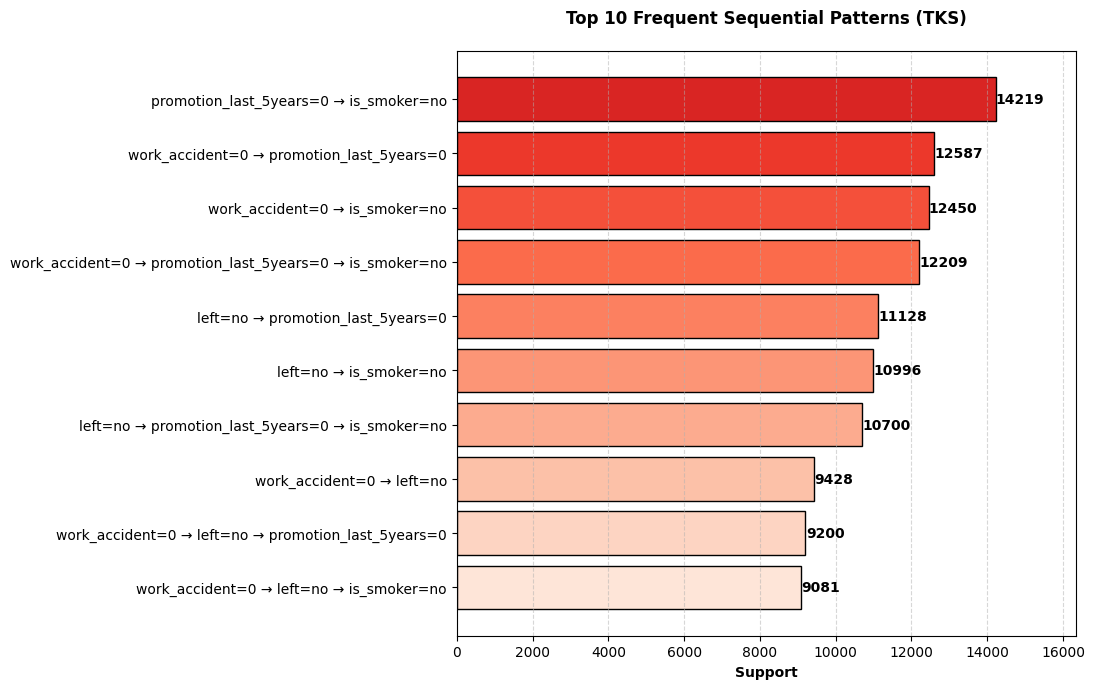

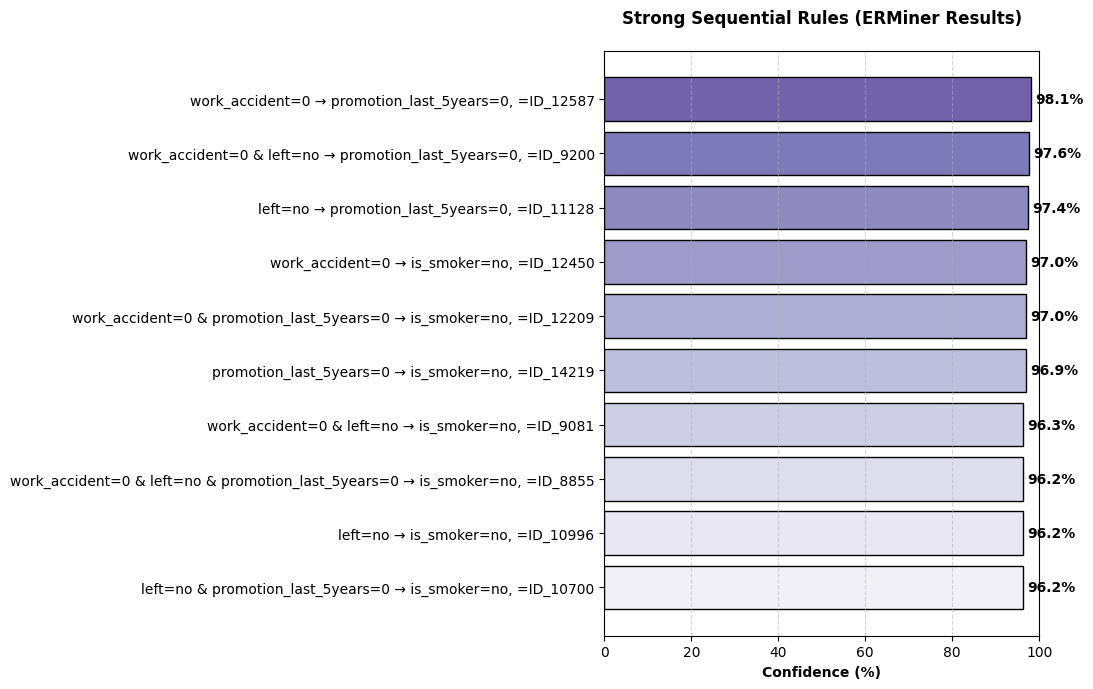


E(3A)CSPM pipeline completed successfully!


In [ ]:
# ============================================================
# E(3A)CSPM: Employee Attrition Prediction using Sequential Pattern Mining
# Dataset: HRA (HR Analytics - Kaggle)
# Paper: Nawaz et al., Computers in Industry, 2024
# Features: ML-based imputation for 'is_smoker'
# ============================================================

import pandas as pd, numpy as np, os, subprocess, time
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from imblearn.over_sampling import SMOTE

# ============================================================
# 1. DOWNLOAD SPMF
# ============================================================
def download_spmf():
    if not os.path.exists("spmf.jar"):
        print("Downloading SPMF...")
        subprocess.run(["wget", "-q", "-O", "spmf.jar",
                        "http://www.philippe-fournier-viger.com/spmf/spmf.jar"])
        print("SPMF downloaded.")
    else:
        print("SPMF already exists.")

# ============================================================
# 2. ML-BASED IMPUTATION FOR 'is_smoker'
# ============================================================
def ml_impute_smoker(df, smoker_col='is_smoker'):
    df = df.copy()
    print(f"\nImputing missing values in '{smoker_col}' using Random Forest...")

    known = df[df[smoker_col].notna()]
    unknown = df[df[smoker_col].isna()]

    if len(unknown) == 0:
        print("No missing values. Skipping.")
        return df

    print(f"Known: {len(known)}, Unknown: {len(unknown)}")

    # Features (exclude target, ID, smoker)
    exclude = [smoker_col, 'left', 'employee_id', 'id']
    feature_cols = [c for c in df.columns if c not in exclude]

    X_known = known[feature_cols].copy()
    y_known = known[smoker_col]
    X_unknown = unknown[feature_cols].copy()

    # Encode categoricals
    le_dict = {}
    for col in X_known.select_dtypes(include='object').columns:
        le = LabelEncoder()
        combined = pd.concat([X_known[col], X_unknown[col]], axis=0).astype(str)
        le.fit(combined)
        X_known[col] = le.transform(X_known[col].astype(str))
        X_unknown[col] = le.transform(X_unknown[col].astype(str))
        le_dict[col] = le

    # Train RF
    clf = RandomForestClassifier(
        n_estimators=200, max_depth=12, random_state=42, class_weight='balanced'
    )
    clf.fit(X_known, y_known)

    # Predict
    y_pred = clf.predict(X_unknown)
    df.loc[df[smoker_col].isna(), smoker_col] = y_pred

    print(f"Imputed {len(unknown)} values.")
    print(f"Predicted: {pd.Series(y_pred).value_counts().to_dict()}")

    # Optional: Show top predictors
    importances = pd.Series(clf.feature_importances_, index=feature_cols).sort_values(ascending=False)
    print("\nTop 5 predictors of smoking status:")
    print(importances.head(5))

    return df

# ============================================================
# 3. LOAD DATASET + IMPUTE
# ============================================================
def load_dataset(path, target_col='left', smoker_col='is_smoker'):
    df = pd.read_csv(path)
    print(f"Loaded {path}: {df.shape[0]} rows, {df.shape[1]} columns")

    # Impute smoker
    if smoker_col in df.columns:
        print(f"Before: {df[smoker_col].isna().sum()} missing in '{smoker_col}'")
        df = ml_impute_smoker(df, smoker_col)
    else:
        print(f"'{smoker_col}' not found. Skipping imputation.")

    df = df.fillna("Unknown").astype(str)
    return df, target_col

# ============================================================
# 4. SPMF INPUT & MAPPING
# ============================================================
def create_mapping(df):
    mapping = {}
    idx = 1
    for col in df.columns:
        for val in df[col].unique():
            mapping[(col, val)] = idx
            idx += 1
    print(f"Mapping: {len(mapping)} unique (col,val) pairs")
    return mapping

def to_spmf(df, mapping, filename):
    seqs = []
    for _, row in df.iterrows():
        s = []
        prev = None
        for c in df.columns:
            item = mapping[(c, row[c])]
            if item != prev:
                s.extend([str(item), "-1"])
                prev = item
        s.append("-2")
        seqs.append(" ".join(s))
    with open(filename, "w") as f:
        f.write("\n".join(seqs))
    print(f"SPMF input saved: {filename} ({len(seqs)} sequences)")

# ============================================================
# 5. RUN SPMF ALGORITHMS
# ============================================================
def run_tks(inp, out, k=500):
    print(f"Running TKS (k={k})...")
    res = subprocess.run(["java", "-Xmx4g", "-jar", "spmf.jar", "run", "TKS", inp, out, str(k)],
                         capture_output=True, text=True)
    print("TKS completed." if res.returncode == 0 else f"TKS failed: {res.stderr}")

def run_erminer(inp, out, minsup="50%", minconf="60%"):
    print(f"Running ERMiner (minsup={minsup}, minconf={minconf})...")
    res = subprocess.run(["java", "-Xmx4g", "-jar", "spmf.jar", "run", "ERMiner", inp, out, minsup, minconf],
                         capture_output=True, text=True)
    print("ERMiner completed." if res.returncode == 0 else f"ERMiner failed: {res.stderr}")

# ============================================================
# 6. MODEL DICTIONARY
# ============================================================
def model_dict():
    return {
        "MNB": MultinomialNB(alpha=1.0),
        "GNB": GaussianNB(),
        "DT": DecisionTreeClassifier(random_state=42),
        "RF": RandomForestClassifier(n_estimators=100, random_state=42),
        "MLP": MLPClassifier(hidden_layer_sizes=(400,), activation='tanh',
                             solver='adam', max_iter=1500, random_state=42),
        "SVM": SVC(kernel='rbf', gamma='scale', random_state=42),
        "kNN": KNeighborsClassifier(n_neighbors=3),
        "LR": LogisticRegression(max_iter=500, random_state=42)
    }

# ============================================================
# 7. CASE 1: Original Features
# ============================================================
def case1(df, target, dataset):
    print(f"\n{'='*60}\nCASE 1: {dataset} – Original Features\n{'='*60}")
    df = df.copy()
    le = LabelEncoder()
    for c in df.select_dtypes(include='object').columns:
        if c != target:
            df[c] = le.fit_transform(df[c])
    df[target] = le.fit_transform(df[target])

    X = df.drop(columns=[target])
    y = df[target]
    X = MinMaxScaler().fit_transform(X)
    models = model_dict()
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    print("\nWithout SMOTE")
    for n, m in models.items():
        t = time.time()
        scores = cross_val_score(m, X, y, cv=cv, scoring='accuracy')
        print(f"{n}: {scores.mean()*100:.2f}% (±{scores.std()*100:.2f}%) ({time.time()-t:.2f}s)")

    print("\nWith SMOTE")
    for n, m in models.items():
        t = time.time()
        sm_scores = []
        for tr, ts in cv.split(X, y):
            Xtr, Xts = X[tr], X[ts]
            ytr, yts = y.iloc[tr], y.iloc[ts]
            Xr, yr = SMOTE(random_state=42).fit_resample(Xtr, ytr)
            m.fit(Xr, yr)
            sm_scores.append(m.score(Xts, yts))
        print(f"{n}: {np.mean(sm_scores)*100:.2f}% (±{np.std(sm_scores)*100:.2f}%) ({time.time()-t:.2f}s)")

# ============================================================
# 8. CASE 2: Sequential Pattern Features
# ============================================================
def parse_tks(file, min_length=2):
    patterns = []
    if not os.path.exists(file):
        return patterns
    for line in open(file):
        if "#SUP:" in line:
            p, sup = line.split("#SUP:")
            items = [int(x) for x in p.split() if x not in ["-1", "-2", ""]]
            if len(items) >= min_length:
                patterns.append((items, int(sup.strip())))
    patterns.sort(key=lambda x: x[1], reverse=True)
    print(f"Parsed {len(patterns)} TKS patterns (length ≥ {min_length})")
    return patterns[:100]

def pattern_features(df, mapping, patterns, target):
    rev = {v: (c, val) for (c, val), v in mapping.items()}
    df_s = df.astype(str)
    n = len(df)
    mat = np.zeros((n, len(patterns)), dtype=np.int8)
    for i, (p, _) in enumerate(patterns):
        pairs = [rev[x] for x in p if x in rev]
        for r in range(n):
            if all(df_s.iloc[r][c] == val for c, val in pairs):
                mat[r, i] = 1
    feat = pd.DataFrame(mat, columns=[f"P{i+1}" for i in range(len(patterns))])
    feat[target] = df[target].values
    print(f"Pattern matrix: {feat.shape}")
    return feat

def case2(df, mapping, patterns, target, dataset):
    print(f"\n{'='*60}\nCASE 2: {dataset} – Sequential Pattern Features\n{'='*60}")
    dfp = pattern_features(df, mapping, patterns, target)
    X = dfp.drop(columns=[target])
    y = LabelEncoder().fit_transform(dfp[target])
    X = MinMaxScaler().fit_transform(X)
    models = model_dict()
    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    for n, m in models.items():
        t = time.time()
        scores = cross_val_score(m, X, y, cv=cv, scoring='accuracy')
        print(f"{n}: {scores.mean()*100:.2f}% (±{scores.std()*100:.2f}%) ({time.time()-t:.2f}s)")

# ============================================================
# 9. VISUALIZATION: Top 10 TKS Patterns
# ============================================================
def plot_top_patterns(df, mapping, tks_file, save_path="top10_tks_hra.png"):
    patterns = parse_tks(tks_file, min_length=2)[:10]
    if not patterns:
        print("No patterns to plot.")
        return

    decoded = []
    supports = []
    rev = {v: (c, val) for (c, val), v in mapping.items()}
    for items, sup in patterns:
        dec = []
        for i in items:
            if i in rev:
                c, v = rev[i]
                dec.append(f"{c}={v}")
            else:
                dec.append(f"ID_{i}")
        decoded.append(" → ".join(dec))
        supports.append(sup)

    plt.figure(figsize=(11, 7))
    colors = plt.cm.Reds_r(np.linspace(0.3, 0.9, len(decoded)))[::-1]
    bars = plt.barh(range(len(decoded)), supports[::-1], color=colors, edgecolor='black')
    plt.yticks(range(len(decoded)), decoded[::-1])
    plt.xlabel('Support', fontweight='bold')
    plt.title('Top 10 Frequent Sequential Patterns (TKS)', fontweight='bold', pad=20)
    for i, (bar, sup) in enumerate(zip(bars, supports[::-1])):
        plt.text(sup + 10, bar.get_y() + bar.get_height()/2, f'{sup}', va='center', ha='left', fontweight='bold')
    plt.xlim(0, max(supports) * 1.15)
    plt.grid(axis='x', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

# ============================================================
# 10. VISUALIZATION: Top 10 ERMiner Rules
# ============================================================
def plot_top_rules(df, mapping, rules_file, save_path="top10_rules_hra.png"):
    rules = []
    with open(rules_file) as f:
        for line in f:
            if '==>' in line and '#SUP:' in line and '#CONF:' in line:
                parts = line.strip().split(' ==> ')
                ant = [int(x) for x in parts[0].split(',') if x.strip().isdigit()]
                rest = parts[1].split('#SUP:')[1]
                sup = int(rest.split('#CONF:')[0].strip())
                conf = float(rest.split('#CONF:')[1].strip())
                rules.append((ant, [int(x) for x in parts[1].split() if x.strip().isdigit() and x != '#SUP:'], sup, conf))
    rules.sort(key=lambda x: x[3], reverse=True)
    top10 = rules[:10]

    decoded = []
    confs = []
    rev = {v: (c, val) for (c, val), v in mapping.items()}
    for ant, con, sup, conf in top10:
        a = " & ".join([f"{rev.get(i, ('', f'ID_{i}'))[0]}={rev.get(i, ('', f'ID_{i}'))[1]}" for i in ant]) if ant else ""
        c = ", ".join([f"{rev.get(i, ('', f'ID_{i}'))[0]}={rev.get(i, ('', f'ID_{i}'))[1]}" for i in con])
        decoded.append(f"{a} → {c}" if a else f"→ {c}")
        confs.append(conf * 100)

    plt.figure(figsize=(11, 7))
    colors = plt.cm.Purples_r(np.linspace(0.3, 0.9, len(decoded)))[::-1]
    bars = plt.barh(range(len(decoded)), confs[::-1], color=colors, edgecolor='black')
    plt.yticks(range(len(decoded)), decoded[::-1])
    plt.xlabel('Confidence (%)', fontweight='bold')
    plt.title('Strong Sequential Rules (ERMiner Results)', fontweight='bold', pad=20)
    for i, (bar, c) in enumerate(zip(bars, confs[::-1])):
        plt.text(c + 1, bar.get_y() + bar.get_height()/2, f'{c:.1f}%', va='center', ha='left', fontweight='bold')
    plt.xlim(0, 100)
    plt.grid(axis='x', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

# ============================================================
# MAIN EXECUTION
# ============================================================
def main():
    download_spmf()

    # Load + Impute
    df, target = load_dataset("hr_data.csv", target_col='left', smoker_col='is_smoker')

    # SPMF Pipeline
    mapping = create_mapping(df)
    to_spmf(df, mapping, "hra_spmf_input.txt")
    run_tks("hra_spmf_input.txt", "hra_tks.txt", k=500)
    run_erminer("hra_spmf_input.txt", "hra_rules.txt", minsup="50%", minconf="60%")

    # Evaluations
    case1(df, target, "HRA")
    patterns = parse_tks("hra_tks.txt")
    if patterns:
        case2(df, mapping, patterns, target, "HRA")

    # Visualizations
    plot_top_patterns(df, mapping, "hra_tks.txt")
    plot_top_rules(df, mapping, "hra_rules.txt")

    print("\nE(3A)CSPM pipeline completed successfully!")

# ============================================================
# RUN
# ============================================================
if __name__ == "__main__":
    main()